<a href="https://colab.research.google.com/github/sararahman1729/Code-Alpha/blob/Task-2/CodeAlpha_Task2(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Verification Step

device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found - Running on CPU mode.')
else:
  print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


In [2]:
# Load and Prepare Data
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize and Reshape
x_train = x_train.reshape((-1, 28, 28, 1)).astype('float32') / 255.0
x_test = x_test.reshape((-1, 28, 28, 1)).astype('float32') / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# CNN Architecture
model = models.Sequential([
    # First Convolutional block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flattening and Dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2), # Prevents overfitting
    layers.Dense(10, activation='softmax') # 10 classes for digits 0-9
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [6]:
#Training for 5-10 epochs
history = model.fit(x_train, y_train, epochs=5,
                    validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9556 - loss: 0.1455 - val_accuracy: 0.9846 - val_loss: 0.0463
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9847 - loss: 0.0496 - val_accuracy: 0.9896 - val_loss: 0.0326
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9893 - loss: 0.0347 - val_accuracy: 0.9930 - val_loss: 0.0234
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9917 - loss: 0.0268 - val_accuracy: 0.9894 - val_loss: 0.0339
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9930 - loss: 0.0207 - val_accuracy: 0.9912 - val_loss: 0.0271


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step
Predicted Digit: 2


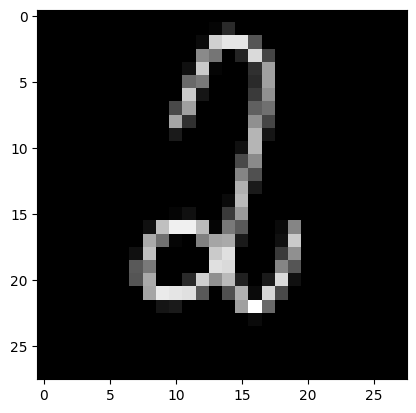

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
def predict_digit(image_path):

    img = Image.open(image_path).convert('L').resize((28, 28))
    img = np.invert(img)
    img = np.array(img) / 255.0
    img = img.reshape(1, 28, 28, 1)

    prediction = model.predict(img)

    print(f"Predicted Digit: {np.argmax(prediction)}")

    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.show()

predict_digit('/content/t2_digit.png')